# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import requests
from bs4 import BeautifulSoup
import time

import re
import os

# Config

In [2]:
session = requests.Session()

session.headers.update({
    "User-Agent": "Mozilla/5.0 (educational web scraping project)"
})

START = 1
END = 5000
STEP = 1000

rows = []

USE_CACHED_DATA = False
CACHED_FILE = "minor_planet.csv"

# Scraper

In [3]:
def parse_minor_planet_row(cells):
    designation = cells[0].get_text(" ", strip=True)
    number_match = re.match(r"^\s*(\d+)", designation)

    if not number_match:
        return None

    number = int(number_match.group(1))
    discovery_date = cells[3].get_text(" ", strip=True)
    discovery_site = cells[4].get_text(" ", strip=True)
    discoverer = cells[5].get_text(" ", strip=True)
    category = cells[6].get_text(" ", strip=True)
    diameter_text = cells[7].get_text(" ", strip=True)

    diameter_match = re.search(r"([\d,.]+)\s*(km|m)\b", diameter_text)

    if diameter_match:
        diameter = float(
            diameter_match.group(1).replace(",", "")
        )

        unit = diameter_match.group(2)

        diameter_km = (
            diameter / 1000
            if unit == "m"
            else diameter
        )

    else:
        diameter_km = None

    return {
        "number": number,
        "discovery_date": discovery_date,
        "discovery_site": discovery_site,
        "discoverer": discoverer,
        "category": category,
        "diameter_km": diameter_km,
    }


def scrape_minor_planets_page(url):
    response = session.get(url, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    tables = soup.find_all("table", class_="wikitable")

    page_rows = []
    for table in tables:
        for tr in table.find_all("tr"):
            cells = tr.find_all(["td", "th"])

            if len(cells) < 8:
                continue

            row = parse_minor_planet_row(cells)
            if row is not None:
                page_rows.append(row)

    return page_rows


def scrape_minor_planets(start, end):
    rows = []
    for page_start in range(start, end + 1, STEP):
        page_end = min(page_start + STEP - 1, end)
        url = f"https://en.wikipedia.org/wiki/List_of_minor_planets:_{page_start}–{page_end}"
        print(f"Scraping {page_start:,}–{page_end:,}...")
        rows.extend(scrape_minor_planets_page(url))

    return rows

# Dataframe Generation

In [4]:
if USE_CACHED_DATA and os.path.exists(CACHED_FILE):
    print(f"Loading cached data from {CACHED_FILE}...")
    df = pd.read_csv(CACHED_FILE)
else:
    print("Scraping data from Wikipedia...")
    rows = scrape_minor_planets(START, END)
    df = pd.DataFrame(rows)
    df.to_csv(CACHED_FILE, index=False)
    print(f"Data saved to {CACHED_FILE}.")

df.head()

Scraping data from Wikipedia...
Scraping 1–1,000...
Scraping 1,001–2,000...
Scraping 2,001–3,000...
Scraping 3,001–4,000...
Scraping 4,001–5,000...
Data saved to minor_planet.csv.


,number,discovery_date,discovery_site,discoverer,category,diameter_km
0,1,"January 1, 1801",Palermo,G. Piazzi,·,939.0
1,2,"March 28, 1802",Bremen,H. W. Olbers,PAL,513.0
2,3,"September 1, 1804",Sternwarte Lilienthal,K. Harding,JUN,247.0
3,4,"March 29, 1807",Bremen,H. W. Olbers,V,523.0
4,5,"December 8, 1845",Driesen,K. L. Hencke,(5),107.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number          5000 non-null   int64  
 1   discovery_date  5000 non-null   str    
 2   discovery_site  5000 non-null   str    
 3   discoverer      5000 non-null   str    
 4   category        5000 non-null   str    
 5   diameter_km     5000 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 234.5 KB


| Atribut | Tipe Atribut | Penjelasan |
|---|---|---|
| `discovery_date` | Ordinal / temporal | Tanggal memiliki urutan kronologis yang jelas. Bisa diubah menjadi tahun/bulan untuk analisis numerik temporal. |
| `discovery_site` | Nominal | Nama lokasi penemuan, tidak memiliki urutan alami. |
| `discoverer` | Nominal | Nama individu, kelompok, atau institusi penemu, tanpa tingkatan atau urutan. |
| `category` | Nominal | Kategori planet kecil seperti EOS, THM, KOR, dan sebagainya. Tidak memiliki urutan alami. |
| `diameter_km` | Numerik kontinu | Diameter dapat mengambil nilai pecahan dan memiliki makna pengukuran kuantitatif. |

# Prep

In [6]:
df["discovery_date"] = pd.to_datetime(df["discovery_date"], errors="coerce")

df["category"] = df["category"].replace({"—": np.nan, "": np.nan, "·": np.nan})

# EDA

# Statistics

In [7]:
df.describe(include="str").T

,count,unique,top,freq
discovery_site,5000,132,Heidelberg,797
discoverer,5000,379,K. Reinmuth,373
category,2120,196,EOS,270


In [8]:
df.describe()

,number,discovery_date,diameter_km
count,5000.000000,5000,5000.000000
mean,2500.500000,1952-06-13 03:34:50.880000,26.843626
min,1.000000,1801-01-01 00:00:00,0.250000
25%,1250.750000,1929-10-05 00:00:00,7.500000
50%,2500.500000,1968-04-07 00:00:00,14.000000
75%,3750.250000,1981-03-02 00:00:00,30.000000
max,5000.000000,1991-08-15 00:00:00,939.000000
std,1443.520003,NaN,37.355467


## Missingness

In [9]:
df.isna().sum()[df.isna().sum() > 0]

category    2880
dtype: int64

In [10]:
df.isna().sum()[df.isna().sum() > 0].apply(lambda x: f"{x/len(df) * 100:.2f}%")

category    57.60%
dtype: str

<Axes: >

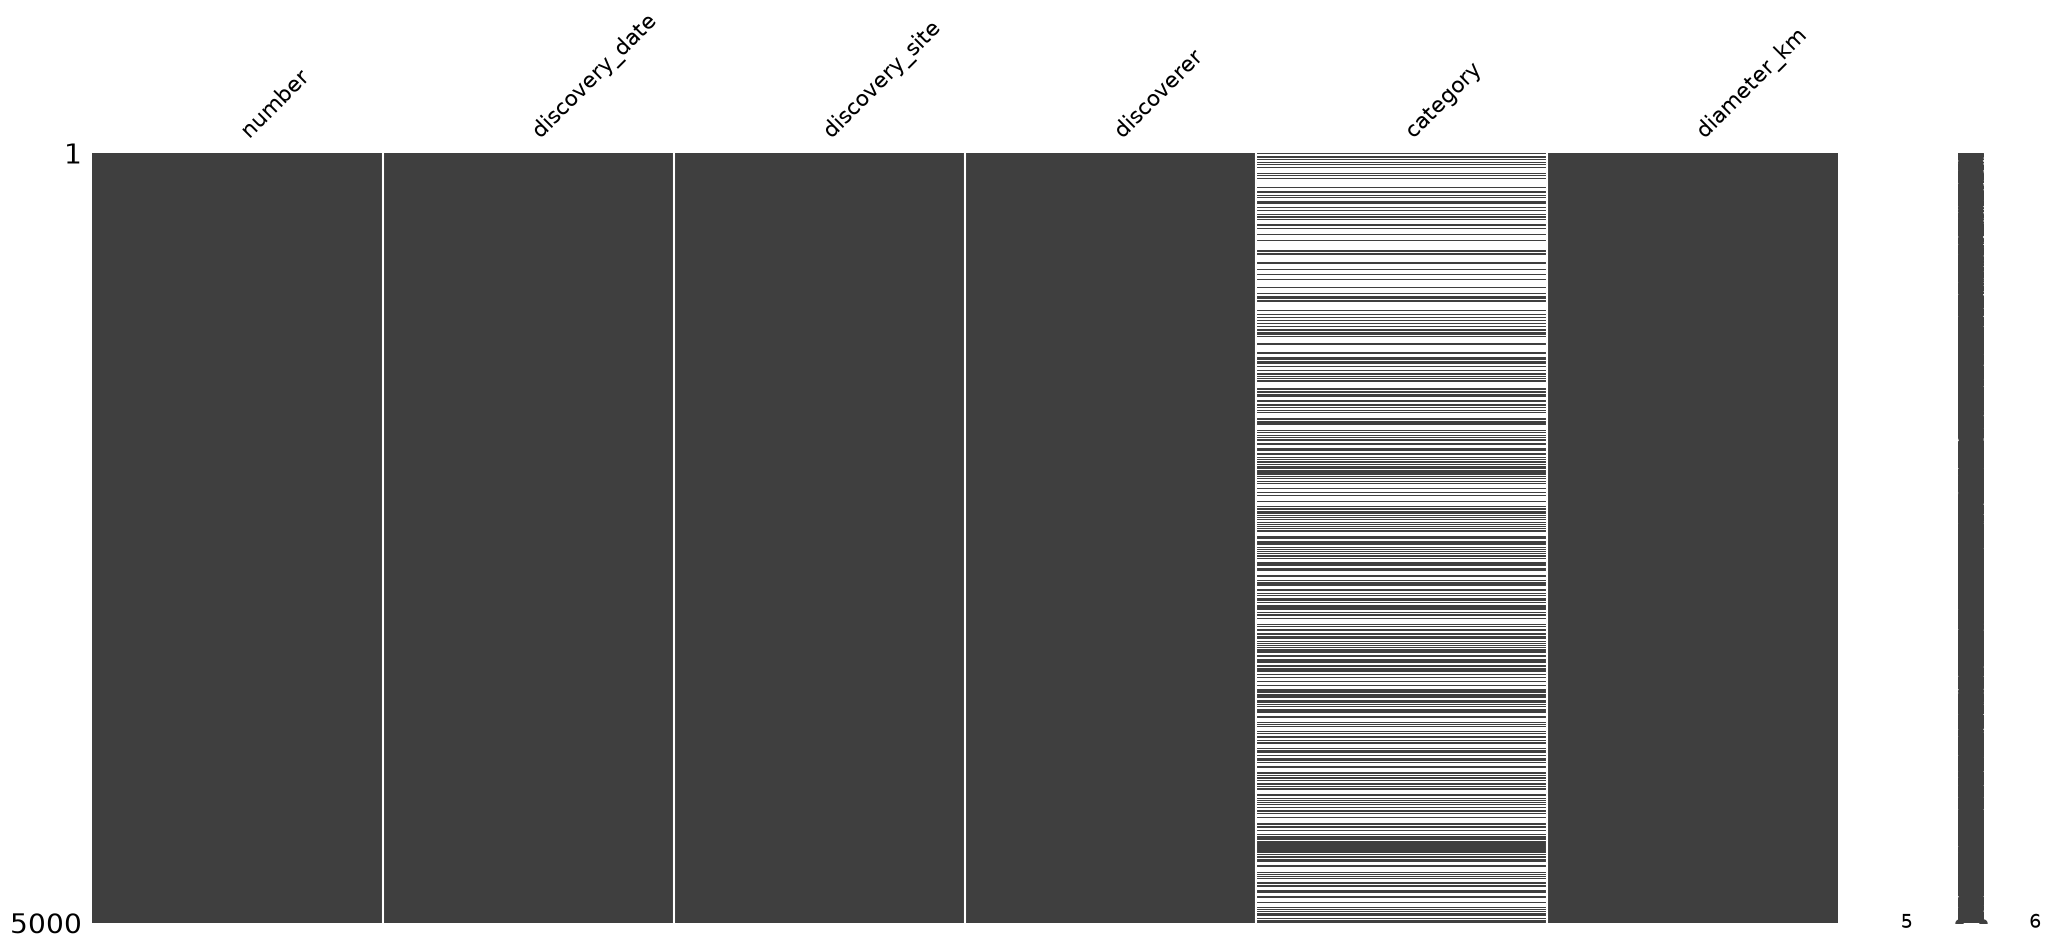

In [11]:
msno.matrix(df)

Dari 5.000 observasi, missing value hanya ditemukan pada variabel category, sebanyak 2.880 observasi (57,60%). Variabel lainnya memiliki data lengkap. Karena tingkat missingness pada category cukup tinggi, penghapusan seluruh observasi yang memiliki nilai kosong tidak disarankan karena akan menghilangkan lebih dari setengah dataset. Nilai kosong tersebut dapat dipertahankan atau diperlakukan sebagai kategori "Unknown" pada analisis selanjutnya.

In [12]:
df['category'] = df['category'].fillna('Unknown')

## Numerics

<Axes: xlabel='diameter_km', ylabel='Count'>

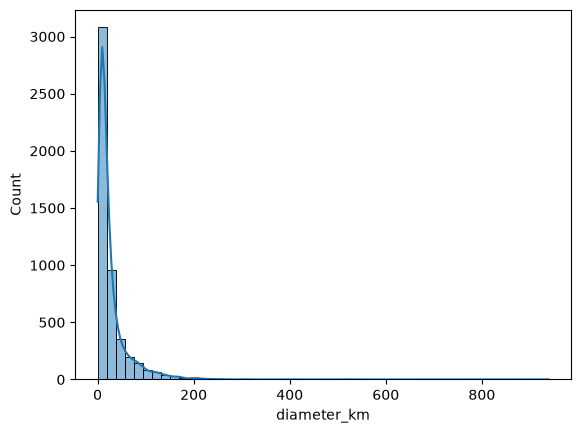

In [27]:
sns.histplot(df, x="diameter_km", bins=50, kde=True)

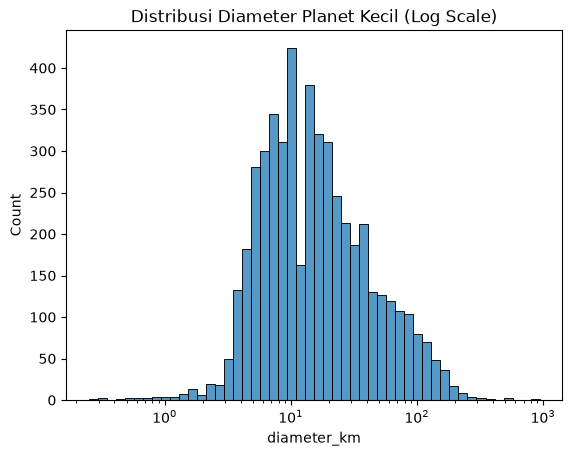

In [14]:
sns.histplot(
    data=df,
    x="diameter_km",
    bins=50,
    log_scale=True
)

plt.title("Distribusi Diameter Planet Kecil (Log Scale)")
plt.show()

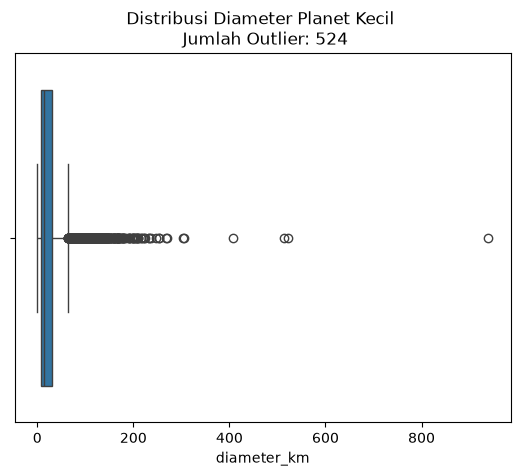

In [29]:
def outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).sum()

sns.boxplot(df, x="diameter_km")

plt.title(f"Distribusi Diameter Planet Kecil \n Jumlah Outlier: {outlier_count(df['diameter_km'])}")
plt.show()

Distribusi diameter_km menunjukkan pola yang sangat right-skewed. Sebagian besar planet kecil memiliki diameter yang relatif kecil, sedangkan hanya sedikit objek yang memiliki diameter sangat besar. Boxplot menunjukkan terdapat 524 observasi yang teridentifikasi sebagai outlier berdasarkan aturan IQR, terutama pada objek dengan diameter ratusan kilometer.

Pada skala logaritmik, distribusi menjadi lebih jelas dan mendekati bentuk unimodal, dengan konsentrasi terbesar berada pada kisaran sekitar 10 km hingga beberapa puluh kilometer. Transformasi log membantu mengurangi pengaruh nilai ekstrem sehingga pola distribusi utama lebih mudah diamati. Kondisi ini menunjukkan bahwa distribusi diameter tidak normal pada skala asli dan median lebih representatif dibandingkan rata-rata dalam menggambarkan ukuran tipikal planet kecil.

## Date

### Tahun

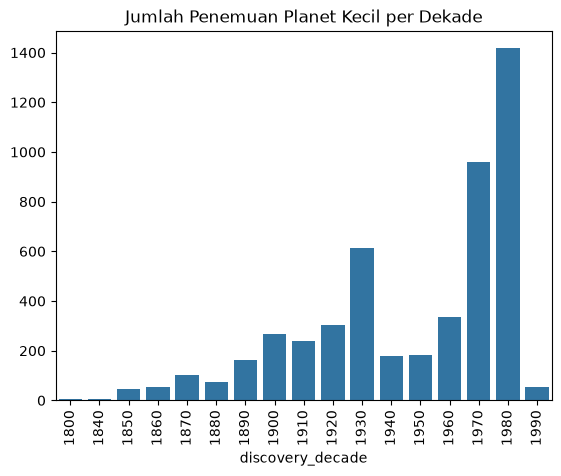

In [16]:
df['discovery_year'] = df['discovery_date'].dt.year
df['discovery_decade'] = (df['discovery_year'] // 10) * 10

sum_discovery_per_decade = df.groupby('discovery_decade').size()

sns.barplot(x=sum_discovery_per_decade.index, y=sum_discovery_per_decade.values)

plt.title("Jumlah Penemuan Planet Kecil per Dekade")
plt.xticks(rotation=90)
plt.show()


Secara umum, jumlah penemuan planet kecil mengalami tren peningkatan dari abad ke-19 hingga abad ke-20, dengan peningkatan paling besar pada dekade 1970-an dan 1980-an. Hal ini mengindikasikan semakin meningkatnya kemampuan observasi astronomi dari waktu ke waktu. Namun, rendahnya jumlah observasi pada dekade 1990-an perlu diinterpretasikan dengan hati-hati karena dataset hanya mencakup 5.000 planet kecil pertama dan bukan seluruh populasi planet kecil yang ditemukan.

### Bulan

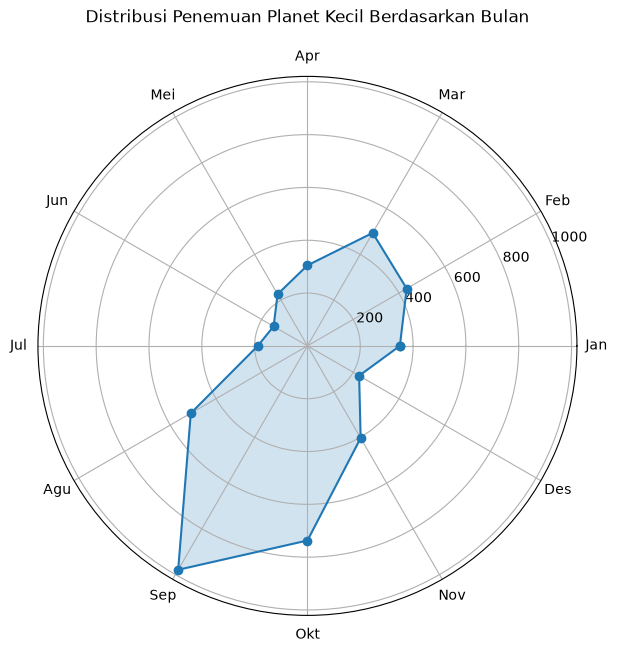

In [17]:
# Distribusi Penemuan Berdasarkan Bulan

import numpy as np
import matplotlib.pyplot as plt

df["discovery_month"] = df["discovery_date"].dt.month

monthly_count = (
    df["discovery_month"]
    .value_counts()
    .reindex(range(1, 13), fill_value=0)
    .sort_index()
)

months = [
    "Jan", "Feb", "Mar", "Apr",
    "Mei", "Jun", "Jul", "Agu",
    "Sep", "Okt", "Nov", "Des"
]

values = monthly_count.values

# Sudut untuk 12 bulan
angles = np.linspace(
    0,
    2 * np.pi,
    12,
    endpoint=False
)

# Tutup radar plot
values_closed = np.append(values, values[0])
angles_closed = np.append(angles, angles[0])

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw={"polar": True}
)

ax.plot(
    angles_closed,
    values_closed,
    marker="o"
)

ax.fill(
    angles_closed,
    values_closed,
    alpha=0.2
)

ax.set_xticks(angles)
ax.set_xticklabels(months)

ax.set_title(
    "Distribusi Penemuan Planet Kecil Berdasarkan Bulan",
    pad=20
)

plt.show()

Distribusi penemuan planet kecil berdasarkan bulan menunjukkan pola yang tidak merata sepanjang tahun. Frekuensi penemuan tertinggi terjadi pada September, dengan jumlah mendekati 1.000 penemuan, diikuti oleh Oktober dan Agustus. Sebaliknya, jumlah penemuan relatif rendah pada periode Mei hingga Juli, dengan titik terendah berada sekitar bulan Juni.

Pola tersebut menunjukkan adanya indikasi seasonality pada waktu penemuan planet kecil dalam dataset. Namun, frekuensi yang lebih tinggi pada bulan tertentu tidak berarti bahwa planet kecil secara intrinsik memiliki peluang lebih besar untuk ditemukan pada bulan tersebut. Distribusi ini juga dapat dipengaruhi oleh faktor lain seperti kondisi cuaca, posisi objek terhadap Bumi dan Matahari, lokasi observatorium, serta intensitas kegiatan survei astronomi pada periode tertentu.

## Categoricals

### Lokasi Penemuan

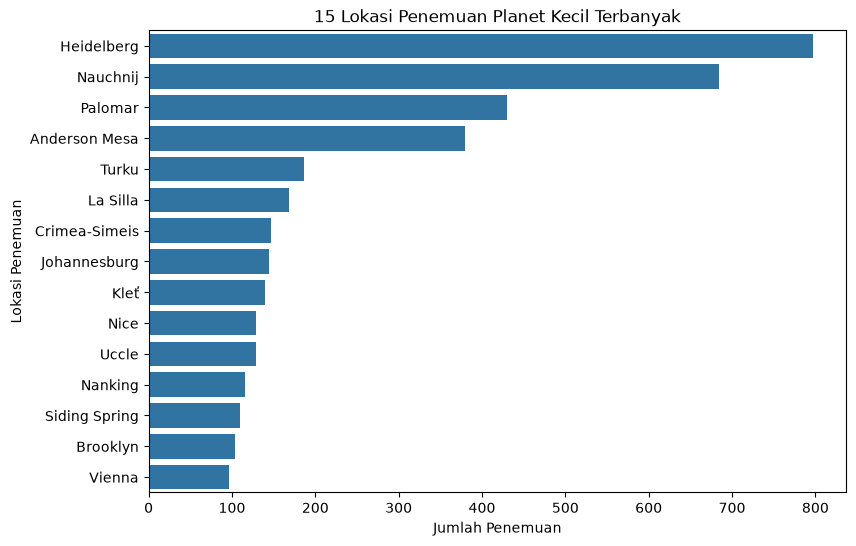

In [18]:
top_sites = (
    df["discovery_site"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top_sites.values,
    y=top_sites.index
)

plt.title("15 Lokasi Penemuan Planet Kecil Terbanyak")
plt.xlabel("Jumlah Penemuan")
plt.ylabel("Lokasi Penemuan")

plt.show()

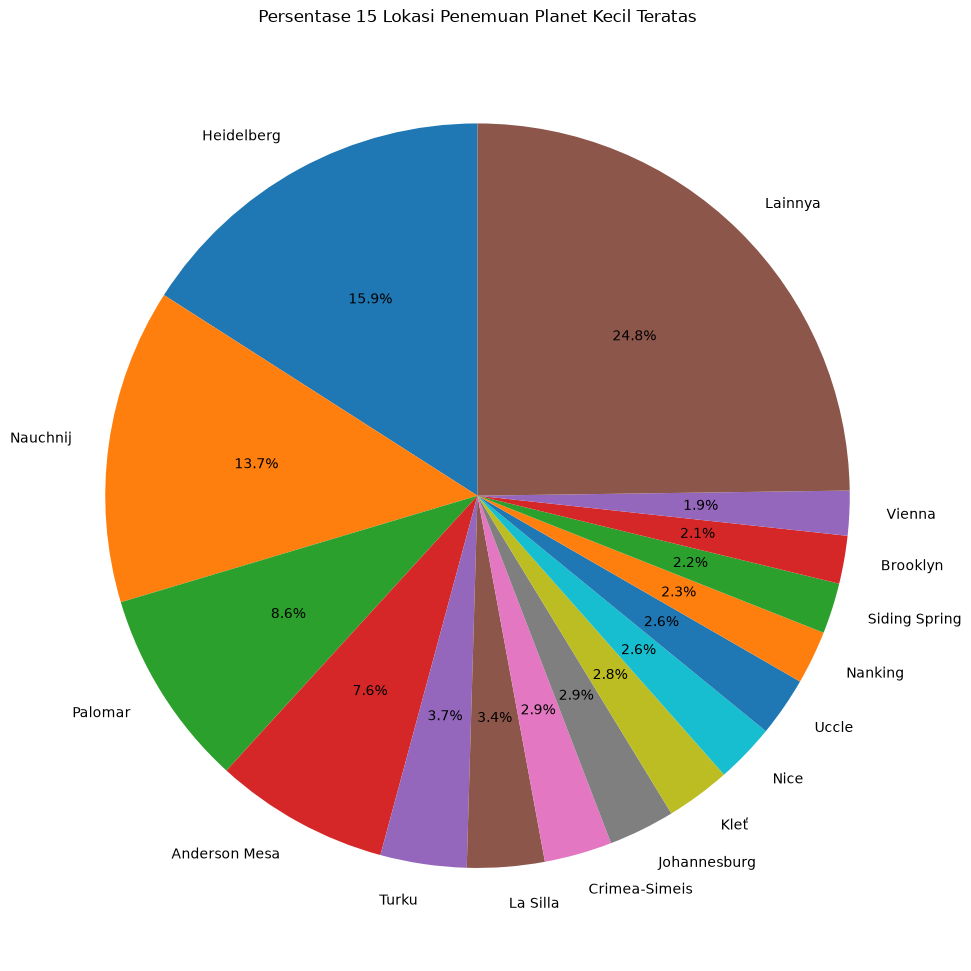

In [19]:
site_counts = df["discovery_site"].value_counts()

top15 = site_counts.head(15)

others = site_counts.iloc[15:].sum()

pie_data = pd.concat([
    top15,
    pd.Series({"Lainnya": others})
])

plt.figure(figsize=(10, 10))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Persentase 15 Lokasi Penemuan Planet Kecil Teratas"
)

plt.tight_layout()
plt.show()

Distribusi lokasi penemuan menunjukkan bahwa aktivitas penemuan planet kecil cukup terkonsentrasi pada beberapa observatorium tertentu. Heidelberg menjadi lokasi dengan jumlah penemuan tertinggi, yaitu sekitar 15,9% dari seluruh observasi, disusul oleh Nauchnij sebesar 13,7%, Palomar sebesar 8,6%, dan Anderson Mesa sebesar 7,6%.

Jika digabungkan, empat lokasi tersebut menyumbang hampir setengah dari seluruh penemuan dalam dataset. Sementara itu, kategori “Lainnya” yang mencakup seluruh lokasi di luar 15 besar masih memberikan kontribusi terbesar secara kolektif, yaitu sekitar 24,8%. Hal ini menunjukkan bahwa meskipun beberapa observatorium sangat dominan, aktivitas penemuan tetap tersebar pada banyak lokasi lain.

Dominasi beberapa lokasi tertentu kemungkinan berkaitan dengan kapasitas observatorium, intensitas program survei, kualitas instrumen, serta lamanya periode operasional. Namun, distribusi ini tidak dapat langsung diartikan bahwa lokasi tersebut secara intrinsik lebih baik untuk menemukan planet kecil tanpa mempertimbangkan faktor historis dan teknologi observasi.

### Penemu

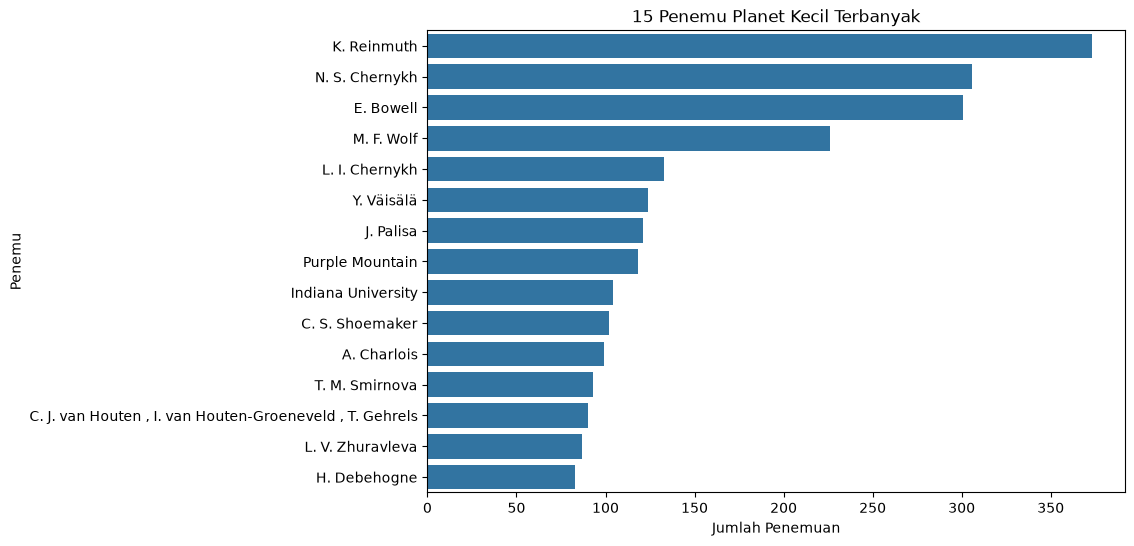

In [20]:
top_discoverers = (
    df["discoverer"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top_discoverers.values,
    y=top_discoverers.index
)

plt.title("15 Penemu Planet Kecil Terbanyak")
plt.xlabel("Jumlah Penemuan")
plt.ylabel("Penemu")

plt.show()

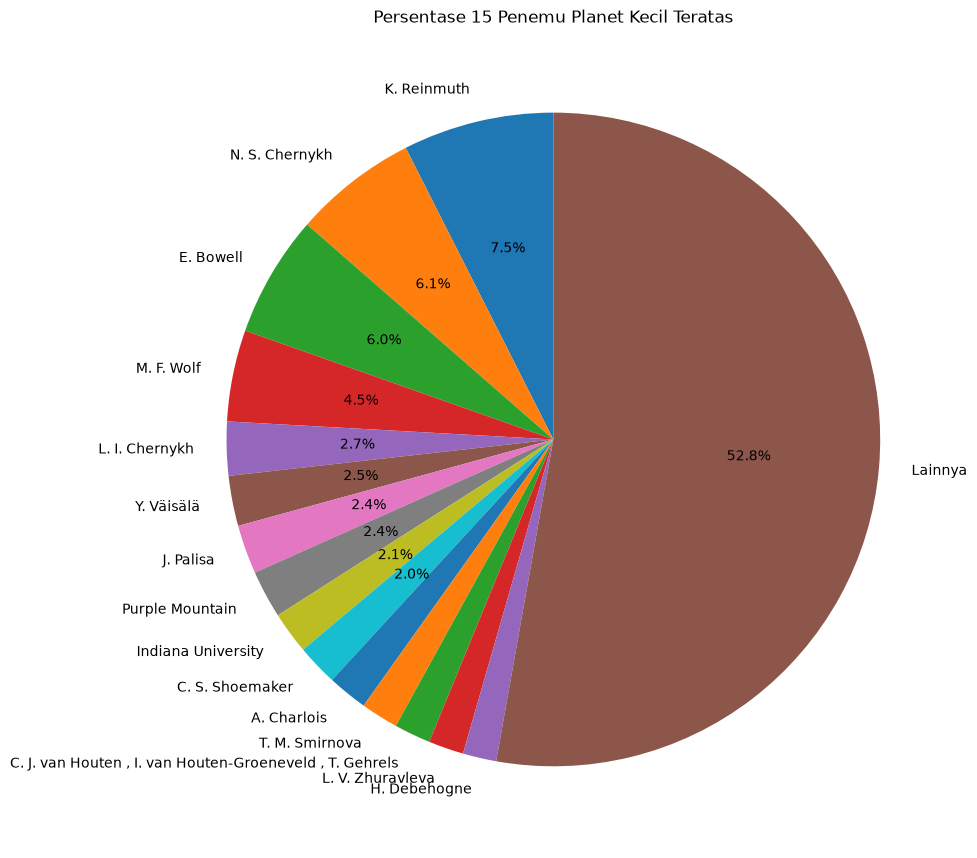

In [21]:
discoverer_counts = df["discoverer"].value_counts()

top15_discoverers = discoverer_counts.head(15)
others = discoverer_counts.iloc[15:].sum()

pie_discoverers = pd.concat([
    top15_discoverers,
    pd.Series({"Lainnya": others})
])

def show_percentage(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

plt.figure(figsize=(10, 10))

plt.pie(
    pie_discoverers.values,
    labels=pie_discoverers.index,
    autopct=show_percentage,
    startangle=90
)

plt.title(
    "Persentase 15 Penemu Planet Kecil Teratas"
)

plt.tight_layout()
plt.show()

Distribusi penemu planet kecil menunjukkan bahwa penemuan tidak terlalu terkonsentrasi pada sejumlah kecil individu. K. Reinmuth menjadi penemu dengan jumlah tertinggi, menyumbang sekitar 7,5% dari seluruh objek dalam dataset. Posisi berikutnya ditempati oleh N. S. Chernykh sebesar 6,1%, E. Bowell sebesar 6,0%, dan M. F. Wolf sebesar 4,5%.

Meskipun beberapa penemu memiliki kontribusi yang cukup besar, kategori “Lainnya” mencapai 52,8%, yang berarti lebih dari separuh penemuan berasal dari penemu di luar 15 besar. Dengan demikian, 15 penemu teratas secara keseluruhan hanya mencakup sekitar 47,2% dari dataset. Hal ini menunjukkan bahwa aktivitas penemuan planet kecil lebih tersebar di antara banyak penemu dibandingkan distribusi lokasi penemuan yang sebelumnya terlihat lebih terkonsentrasi pada beberapa observatorium tertentu.

Selain individu, terdapat pula nama seperti Purple Mountain dan Indiana University, serta kelompok beberapa nama dalam satu entri. Hal ini menunjukkan bahwa kolom discoverer tidak selalu merepresentasikan satu individu, tetapi dapat mencakup institusi maupun tim penemu. Oleh karena itu, hasil ini lebih tepat diinterpretasikan sebagai distribusi berdasarkan entri penemu yang tercatat pada sumber data, bukan sebagai perbandingan produktivitas individu secara murni.

### Kategori temuan

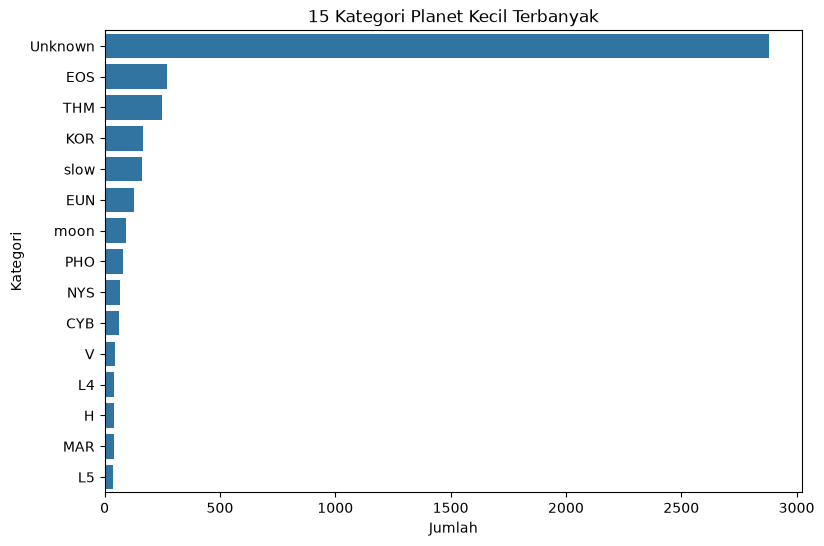

In [22]:
category_counts = (
    df["category"]
    .dropna()
    .value_counts()
)

top15_categories = category_counts.head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top15_categories.values,
    y=top15_categories.index
)

plt.title("15 Kategori Planet Kecil Terbanyak")
plt.xlabel("Jumlah")
plt.ylabel("Kategori")

plt.show()

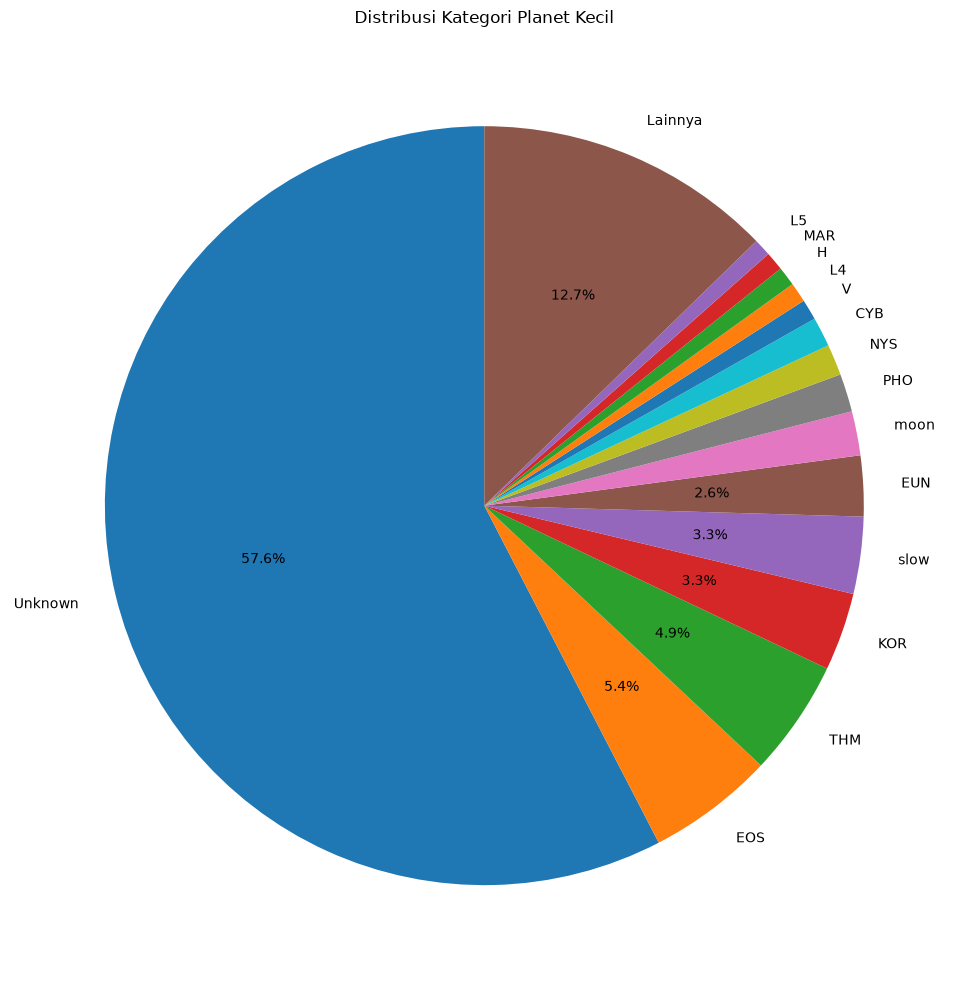

In [23]:
category_counts = df["category"].value_counts()

top15_categories = category_counts.head(15)

others = category_counts.iloc[15:].sum()
unknown = df["category"].isna().sum()

pie_categories = pd.concat([
    top15_categories,
    pd.Series({
        "Lainnya": others
    })
])


plt.figure(figsize=(10, 10))

plt.pie(
    pie_categories.values,
    labels=pie_categories.index,
    autopct=show_percentage,
    startangle=90
)

plt.title(
    "Distribusi Kategori Planet Kecil"
)

plt.tight_layout()
plt.show()

Distribusi kategori planet kecil menunjukkan bahwa sebagian besar observasi belum memiliki informasi kategori, ditunjukkan oleh kelompok Unknown sebesar 57,6% dari keseluruhan dataset. Kondisi ini konsisten dengan analisis missing value sebelumnya, di mana variabel category merupakan satu-satunya variabel dengan tingkat missingness yang tinggi.

Di antara objek yang memiliki kategori, EOS merupakan kategori yang paling banyak ditemukan dengan proporsi sekitar 5,4%, diikuti oleh THM sebesar 4,9%, serta KOR dan slow yang masing-masing sekitar 3,3%. Sementara itu, kategori di luar 15 kategori teratas yang digabungkan menjadi Lainnya menyumbang sekitar 12,7% dari seluruh dataset.

Distribusi ini menunjukkan bahwa kategori planet kecil cukup beragam dan tidak didominasi secara ekstrem oleh satu kategori tertentu setelah observasi tanpa kategori dikeluarkan. Namun, karena lebih dari setengah data kategori tidak tersedia, interpretasi mengenai komposisi kategori harus dilakukan secara hati-hati dan tidak dapat dianggap merepresentasikan distribusi kategori seluruh populasi planet kecil secara langsung.

## Interraction

### Diameter vs Discovery Year

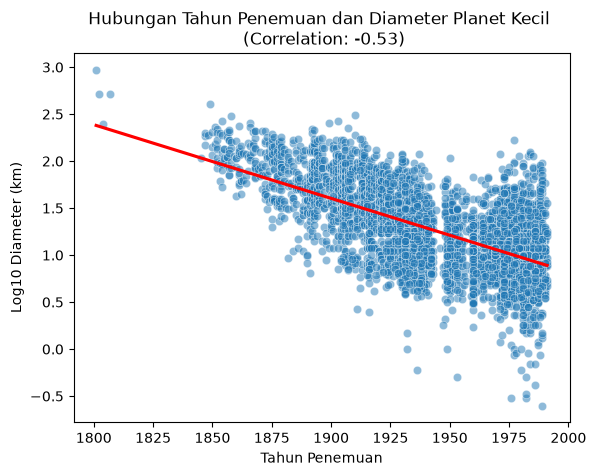

In [24]:
diameter_log = np.log10(df["diameter_km"].dropna())

corr = df[["discovery_year", "diameter_km"]].corr(method="spearman").iloc[0, 1]

plot_df = df.loc[diameter_log.index].copy()
plot_df["diameter_log"] = diameter_log

sns.scatterplot(
    data=plot_df,
    x="discovery_year",
    y="diameter_log",
    alpha=0.5,
)

sns.regplot(
    data=plot_df,
    x="discovery_year",
    y="diameter_log",
    scatter=False,
    color="red",
    label="Linear Fit",
    ci=None,
)

plt.xlabel("Tahun Penemuan")
plt.ylabel("Log10 Diameter (km)")

plt.title(f"Hubungan Tahun Penemuan dan Diameter Planet Kecil \n (Correlation: {corr:.2f})")
plt.show()

Scatter plot menunjukkan adanya hubungan negatif antara tahun penemuan dan diameter planet kecil. Nilai korelasi Spearman sebesar -0,53 menunjukkan hubungan negatif dengan kekuatan sedang. Artinya, planet kecil yang ditemukan pada tahun yang lebih baru cenderung memiliki diameter yang lebih kecil dibandingkan objek yang ditemukan pada periode sebelumnya.

Garis tren yang menurun juga memperkuat pola tersebut. Pada awal periode observasi, objek yang ditemukan umumnya memiliki diameter relatif besar, sedangkan seiring waktu rentang diameter objek yang ditemukan menjadi semakin luas dan mencakup banyak objek berukuran lebih kecil. Penggunaan transformasi log10 pada diameter membantu mengurangi pengaruh nilai ekstrem dan membuat pola hubungan lebih mudah diamati.

Pola ini dapat mengindikasikan perkembangan kemampuan observasi astronomi, di mana peningkatan sensitivitas instrumen dan metode survei memungkinkan pendeteksian objek yang lebih kecil. Namun, hubungan ini tetap bersifat korelasi dan bukan hubungan sebab-akibat, serta dapat dipengaruhi oleh faktor lain seperti metode survei, lokasi observasi, dan karakteristik dataset.